#cafe sales analysis
### Business scenario
you have been hired as a junior data analyst by a cafe. The cafe has provided the transaction data and wants to understand its sales perfomance.

In [96]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [63]:
#load the data
df = pd.read_csv('C:/Users/John.Kariuki.MRCT/Downloads/Data Analytics and Data Apps/dirty_cafe_sales.csv')

In [64]:
# preview the data
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [65]:
# The last five rows
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [ ]:
# sample of the data
df.sample(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
7566,TXN_7057481,Smoothie,3,4.0,12.0,Cash,In-store,2023-07-11
6825,TXN_6889357,Salad,1,5.0,5.0,Cash,Takeaway,2023-03-08
8020,TXN_2547156,Cookie,3,1.0,3.0,Digital Wallet,Takeaway,2023-08-18
7762,TXN_5349355,NaN,2,5.0,10.0,Digital Wallet,In-store,2023-05-10
4877,TXN_9468033,Juice,1,3.0,3.0,Credit Card,NaN,2023-12-13
3347,TXN_2300313,Coffee,4,2.0,8.0,NaN,In-store,2023-06-02
6342,TXN_9861432,Cookie,2,1.0,2.0,NaN,Takeaway,2023-12-09
244,TXN_9642066,Sandwich,3,4.0,12.0,Credit Card,In-store,2023-08-31
9639,TXN_1837764,Tea,3,1.5,4.5,Cash,In-store,2023-07-30
4454,TXN_6991736,Juice,2,3.0,6.0,Digital Wallet,In-store,2023-11-07


In [67]:
# dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


our dataset has missing values and some colums have incorrect data types

In [68]:
#statistical summary
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [69]:
#selecting single columns
df['Item'].head()

0    Coffee
1      Cake
2    Cookie
3     Salad
4    Coffee
Name: Item, dtype: str

In [70]:
#Multiple columns
df[['Item','Price Per Unit']].head()

,Item,Price Per Unit
0,Coffee,2.0
1,Cake,3.0
2,Cookie,1.0
3,Salad,5.0
4,Coffee,2.0


In [71]:
# Checking data type for a specific column
df['Item'].dtype

<StringDtype(storage='python', na_value=nan)>

In [72]:
# checking data types
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

### Data Quality

In [73]:
# are there any missing values
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [74]:
df.isna().sum()


Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [75]:
# Duplicates records
df.duplicated().sum()

np.int64(0)

### Data Cleaning
#### cleaning order:
   1. Hidden errors' UNKNOWN' & 'ERROR'
   2. Fix Data Types
   3. Drop Missing Values


In [76]:
#Remove the hidden errors
invalid_values = ['UNKNOWN','ERROR','NA','?']
# Replace the invalid values with NaN across the entire DataFrame
df.replace(invalid_values, np.nan, inplace = True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [77]:
# Recheck for missing values after replacing invalid values
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [78]:
# fix incorrect data types
# change quantity,price per unit & Total spent to numeric values
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [79]:
# change transaction date to datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [80]:
# Drop the missing values
df = df.dropna()

In [81]:
# Clean Text (coffee,coffee, coffee, Coffee)
df['Item'] = df['Item'].str.strip().str.title()

## validation

In [82]:
# Recheck for missing values
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [83]:
# Recheck dataset shape
df.shape

(3089, 8)

In [84]:
#check the items
df['Item'].unique()

<StringArray>
['Coffee', 'Cake', 'Salad', 'Sandwich', 'Juice', 'Smoothie', 'Cookie', 'Tea']
Length: 8, dtype: str

In [85]:
# Recheck the data types
df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [86]:
# summary statistics
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,3089.000000,3089.000000,3089.000000,3089
mean,3.023632,2.954030,8.936711,2023-07-01 07:14:28.242149
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-03-28 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-06 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-01 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.418931,1.292975,6.032656,NaN


## Business Qestions

In [87]:
# How many sales did each product/item have?
df['Item'].value_counts()

Item
Juice       427
Salad       418
Sandwich    391
Cookie      391
Cake        385
Tea         372
Coffee      367
Smoothie    338
Name: count, dtype: int64

In [88]:
# what is our best seller?
df['Item'].value_counts().idxmax()

'Juice'

In [89]:
# What is the average quantity ordered per transaction?
df['Quantity'].sum()

np.float64(9340.0)

In [90]:
# creating a new column
df['Revenue'] = df['Quantity']*df['Price Per Unit']

In [91]:
# Preview the data
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Revenue
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,25.0
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03,8.0


In [92]:
# Total Revenue
df['Revenue'].sum()

np.float64(27605.5)

In [93]:
# Revenue Per Item
df.groupby('Item')['Revenue'].sum()

Item
Cake        3519.0
Coffee      2242.0
Cookie      1163.0
Juice       3735.0
Salad       6360.0
Sandwich    4772.0
Smoothie    4088.0
Tea         1726.5
Name: Revenue, dtype: float64

In [94]:
# Sort Revenue per item
df.groupby('Item')['Revenue'].sum().sort_values(ascending=False)

Item
Salad       6360.0
Sandwich    4772.0
Smoothie    4088.0
Juice       3735.0
Cake        3519.0
Coffee      2242.0
Tea         1726.5
Cookie      1163.0
Name: Revenue, dtype: float64

In [95]:
# Quantity sold per location
df.groupby('Location')['Revenue'].sum()

Location
In-store    14110.5
Takeaway    13495.0
Name: Revenue, dtype: float64

## Visualization

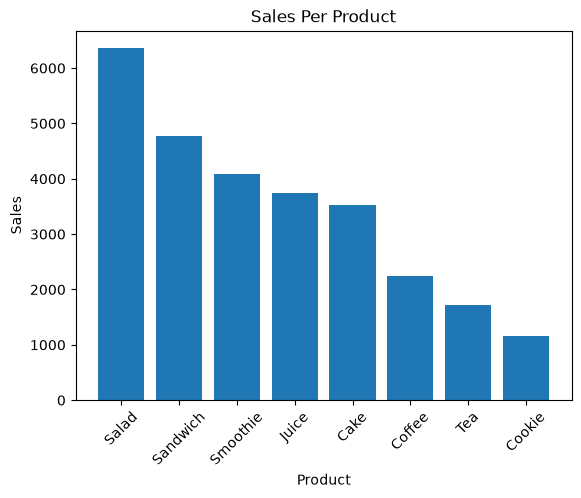

In [99]:
#Sales per product
sales_by_item = df.groupby('Item')['Revenue'].sum().sort_values(ascending=False)
plt.bar(sales_by_item.index, sales_by_item.values)
plt.title('Sales Per Product')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.xticks(rotation = 45)
plt.show()


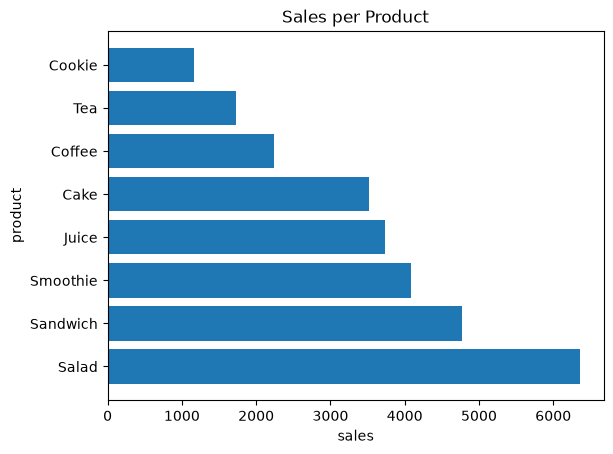

In [100]:
#Horizontal bar chart
plt.barh(sales_by_item.index, sales_by_item.values)
plt.title('Sales per Product')
plt.xlabel('sales')
plt.ylabel('product')
plt.show()

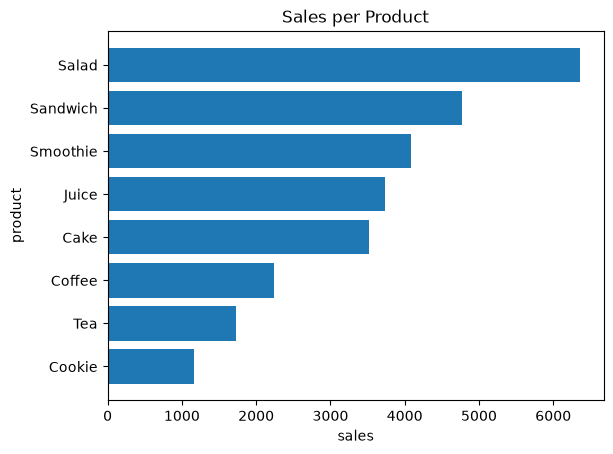

In [102]:
#Horizontal bar chart
plt.barh(sales_by_item.index[::-1], sales_by_item.values[::-1])
plt.title('Sales per Product')
plt.xlabel('sales')
plt.ylabel('product')
plt.show()

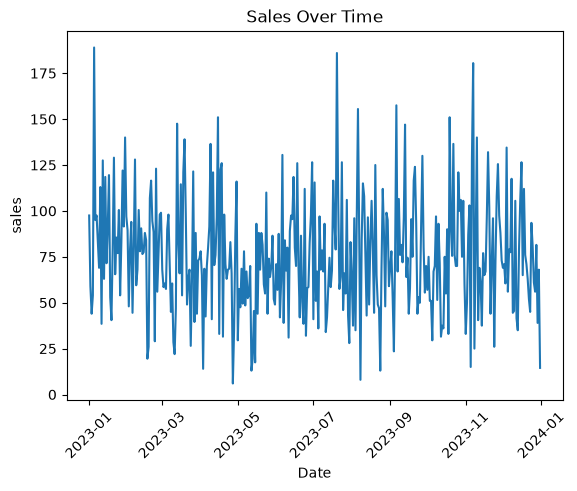

In [104]:
# Sales trend over time
daily_sales = df.groupby('Transaction Date')['Revenue'].sum()
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('sales')
plt.xticks(rotation=45)
plt.show()

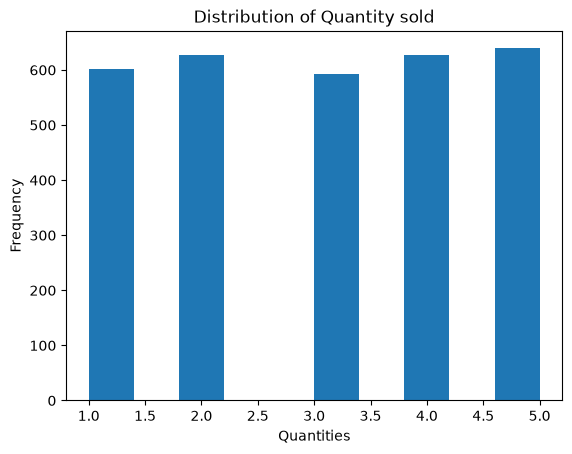

In [105]:
# How the quantities sold are distributed?
plt.hist(df['Quantity'], bins=10)
plt.title('Distribution of Quantity sold')
plt.xlabel('Quantities')
plt.ylabel('Frequency')
plt.show()

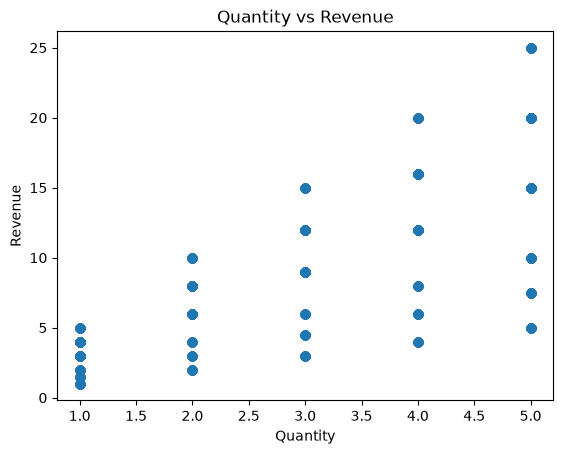

In [106]:
# Is there a relationship between Quantity sold and revenue?
plt.scatter(df['Quantity'], df['Revenue'])
plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.show()